# Gunshot Audio Classification

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchaudio
import torchaudio.transforms as T
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [3]:
# Explore the dataset structure and count files per class
dataset_path = Path('gunshot-audio-dataset')
class_names = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])

print('Dataset classes:')
for class_name in class_names:
    class_path = dataset_path / class_name
    file_count = len(list(class_path.glob('*.wav')))
    print(f'  {class_name}: {file_count} files')

Dataset classes:
  AK-12: 98 files
  AK-47: 72 files
  IMI Desert Eagle: 100 files
  M16: 100 files
  M249: 99 files
  M4: 100 files
  MG-42: 100 files
  MP5: 100 files
  Zastava M92: 82 files


In [4]:
# Check channels across all 851 files
mono_count = 0
stereo_count = 0

for class_name in class_names:
    class_path = dataset_path / class_name
    audio_files = list(class_path.glob('*.wav'))
    for audio_file in audio_files:
        waveform, sr = torchaudio.load(audio_file)
        channels = waveform.shape[0]
        if channels == 1:
            mono_count += 1
        else:
            stereo_count += 1

print(f'Mono files: {mono_count}')
print(f'Stereo files: {stereo_count}')

ImportError: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.

In [5]:
# Check sample rates across all 851 files
sample_rate_counts = {}

for class_name in class_names:
    class_path = dataset_path / class_name
    audio_files = list(class_path.glob('*.wav'))
    for audio_file in audio_files:
        waveform, sr = torchaudio.load(audio_file)
        if sr not in sample_rate_counts:
            sample_rate_counts[sr] = 0
        sample_rate_counts[sr] += 1

for sr, count in sorted(sample_rate_counts.items()):
    print(f'{sr} Hz: {count} files')

ImportError: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.

In [6]:
# Check durations across all audio files
durations = []
duration_counts = {}

for class_name in class_names:
    class_path = dataset_path / class_name
    audio_files = list(class_path.glob('*.wav'))
    for audio_file in audio_files:
        waveform, sr = torchaudio.load(audio_file)
        samples = waveform.shape[1]
        duration = samples / sr
        durations.append(duration)
        duration_rounded = round(duration, 2)
        if duration_rounded not in duration_counts:
            duration_counts[duration_rounded] = 0
        duration_counts[duration_rounded] += 1

shortest = min(durations)
longest = max(durations)
average = sum(durations) / len(durations)

print(f'Shortest duration: {shortest:.2f}s')
print(f'Longest duration: {longest:.2f}s')
print(f'Average duration: {average:.2f}s')
print(f'\nUnique durations: {len(duration_counts)}')
for dur, count in sorted(duration_counts.items()):
    print(f'  {dur:.2f}s: {count} files')

if len(duration_counts) > 5:
    print('\nALERT: Durations vary significantly across files')


ImportError: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.

In [7]:
# Check class imbalance across all audio files
class_file_counts = {}

for class_name in class_names:
    class_path = dataset_path / class_name
    file_count = len(list(class_path.glob('*.wav')))
    class_file_counts[class_name] = file_count

max_count = max(class_file_counts.values())
min_count = min(class_file_counts.values())

print('Class distribution:')
for class_name, count in class_file_counts.items():
    print(f'  {class_name}: {count} files')

if max_count > 2 * min_count:
    print(f'\nClass imbalance detected: max={max_count}, min={min_count}')


Class distribution:
  AK-12: 98 files
  AK-47: 72 files
  IMI Desert Eagle: 100 files
  M16: 100 files
  M249: 99 files
  M4: 100 files
  MG-42: 100 files
  MP5: 100 files
  Zastava M92: 82 files


In [8]:
# Define individual preprocessing functions
def convert_to_mono(waveform):
    if waveform.shape[0] > 1:
        return torch.mean(waveform, dim=0, keepdim=True)
    return waveform

def resample_audio(waveform, orig_sr, target_sr=48000):
    if orig_sr != target_sr:
        resampler = T.Resample(orig_sr, target_sr)
        return resampler(waveform)
    return waveform

def pad_or_crop(waveform, target_length):
    current_length = waveform.shape[1]
    if current_length < target_length:
        padding = target_length - current_length
        waveform = torch.nn.functional.pad(waveform, (0, padding))
    elif current_length > target_length:
        waveform = waveform[:, :target_length]
    return waveform

def apply_preemphasis(waveform, coef=0.97):
    return torch.cat([waveform[:, :1], waveform[:, 1:] - coef * waveform[:, :-1]], dim=1)

def normalize_audio(waveform):
    return waveform / (torch.max(torch.abs(waveform)) + 1e-8)

In [9]:
# Preprocessing pipeline that applies all transformations
def preprocess_audio(file_path, target_sr=48000, target_duration=2.0):
    waveform, sr = torchaudio.load(file_path)
    waveform = convert_to_mono(waveform)
    waveform = resample_audio(waveform, sr, target_sr)
    target_length = int(target_sr * target_duration)
    waveform = pad_or_crop(waveform, target_length)
    waveform = apply_preemphasis(waveform)
    waveform = normalize_audio(waveform)
    return waveform, target_sr

In [10]:
# Process all audio files and save to processed-audio-48k folder
output_path = Path('processed-audio-48k')
output_path.mkdir(exist_ok=True)

print('Preprocessing audio files...')
for class_name in class_names:
    class_output_path = output_path / class_name
    class_output_path.mkdir(exist_ok=True)
    
    class_input_path = dataset_path / class_name
    audio_files = list(class_input_path.glob('*.wav'))
    
    for audio_file in audio_files:
        waveform, sr = preprocess_audio(audio_file)
        output_file = class_output_path / audio_file.name
        torchaudio.save(output_file, waveform, sr)
    
    print(f'  Processed {len(audio_files)} files for {class_name}')

print('Preprocessing complete')

Preprocessing audio files...


ImportError: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.

In [11]:
# Extract MFCC features and save as tensors
features_path = Path('features')
features_path.mkdir(exist_ok=True)

mfcc_transform = T.MFCC(
    sample_rate=48000,
    n_mfcc=40,
    melkwargs={'n_fft': 1024, 'hop_length': 512, 'n_mels': 64}
)

print('Extracting MFCC features...')
for class_name in class_names:
    class_features_path = features_path / class_name
    class_features_path.mkdir(exist_ok=True)
    
    class_processed_path = output_path / class_name
    audio_files = list(class_processed_path.glob('*.wav'))
    
    for audio_file in audio_files:
        waveform, sr = torchaudio.load(audio_file)
        mfcc = mfcc_transform(waveform)
        
        feature_file = class_features_path / f'{audio_file.stem}.pt'
        torch.save(mfcc, feature_file)
    
    print(f'  Extracted features for {len(audio_files)} files in {class_name}')

print('Feature extraction complete')

Extracting MFCC features...


ImportError: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.

In [12]:
# Define class mapping with M16 and M4 merged into M-Family
class_to_idx = {
    'AK-12': 0,
    'AK-47': 1,
    'IMI Desert Eagle': 2,
    'M16': 3,
    'M4': 3,
    'M249': 4,
    'MG-42': 5,
    'MP5': 6,
    'Zastava M92': 7
}

idx_to_class = {
    0: 'AK-12',
    1: 'AK-47',
    2: 'IMI Desert Eagle',
    3: 'M-Family',
    4: 'M249',
    5: 'MG-42',
    6: 'MP5',
    7: 'Zastava M92'
}

print('Class mapping:')
for class_name, idx in class_to_idx.items():
    print(f'  {class_name} → {idx}')

Class mapping:
  AK-12 → 0
  AK-47 → 1
  IMI Desert Eagle → 2
  M16 → 3
  M4 → 3
  M249 → 4
  MG-42 → 5
  MP5 → 6
  Zastava M92 → 7


In [13]:
# Define dataset class for loading MFCC features
class GunshotDataset(Dataset):
    def __init__(self, features_path, class_to_idx, augment=False):
        self.features_path = Path(features_path)
        self.class_to_idx = class_to_idx
        self.augment = augment
        self.samples = []
        
        for class_name in class_to_idx.keys():
            class_path = self.features_path / class_name
            if class_path.exists():
                for feature_file in class_path.glob('*.pt'):
                    self.samples.append((feature_file, class_to_idx[class_name]))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        feature_file, label = self.samples[idx]
        features = torch.load(feature_file, weights_only=True)
        
        if self.augment:
            # Add gaussian noise with 40% probability
            if torch.rand(1).item() > 0.6:
                features = features + torch.randn_like(features) * 0.01
            
            # Apply random time shift with 40% probability
            if torch.rand(1).item() > 0.6:
                shift = torch.randint(-10, 11, (1,)).item()
                features = torch.roll(features, shifts=shift, dims=-1)
        
        return features, label

full_dataset = GunshotDataset('features', class_to_idx, augment=False)
print(f'Total samples: {len(full_dataset)}')

Total samples: 851


In [14]:
# Split dataset into train, validation, and test sets
torch.manual_seed(42)

total_size = len(full_dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset_temp, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

# Create augmented training dataset
train_dataset = GunshotDataset('features', class_to_idx, augment=True)
train_indices = train_dataset_temp.indices
train_dataset.samples = [train_dataset.samples[i] for i in train_indices]

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f'Train: {train_size}, Val: {val_size}, Test: {test_size}')

Train: 595, Val: 127, Test: 129


In [15]:
# Compute inverse frequency class weights to handle imbalance
class_counts = torch.zeros(8)
for _, label in full_dataset:
    class_counts[label] += 1

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
class_weights = class_weights.to(device)
print('Class weights:', class_weights.cpu().numpy().round(4))


Class weights: [0.1254 0.1706 0.1229 0.0614 0.1241 0.1229 0.1229 0.1498]


In [16]:
# CNN architecture with two conv blocks and a fully connected head
class GunshotCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(GunshotCNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [17]:
# Instantiate model, move to device, print trainable parameter count
model = GunshotCNN(num_classes=8).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total: {total_params:,}  Trainable: {trainable:,}')


Total: 564,232  Trainable: 564,232


In [18]:
# Weighted cross-entropy loss, Adam optimizer, cosine annealing scheduler
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=2e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)


In [19]:
# Training hyperparameters and empty history lists
num_epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []


In [20]:
# Training loop with early stopping — saves best model to best of the best.pth
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step()

    print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% - LR: {optimizer.param_groups[0]["lr"]:.6f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best of the best.pth')
        print(f'  Model saved with val_loss: {val_loss:.4f}')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

print('Training complete')


Epoch 1/50 - Train Loss: 2.1243, Train Acc: 10.59% - Val Loss: 2.1036, Val Acc: 5.51% - LR: 0.000500
  Model saved with val_loss: 2.1036
Epoch 2/50 - Train Loss: 2.0954, Train Acc: 10.42% - Val Loss: 2.1196, Val Acc: 5.51% - LR: 0.000498
Epoch 3/50 - Train Loss: 2.0959, Train Acc: 11.43% - Val Loss: 2.0905, Val Acc: 13.39% - LR: 0.000496
  Model saved with val_loss: 2.0905
Epoch 4/50 - Train Loss: 2.0971, Train Acc: 11.09% - Val Loss: 2.0982, Val Acc: 12.60% - LR: 0.000492
Epoch 5/50 - Train Loss: 2.0814, Train Acc: 11.60% - Val Loss: 2.1094, Val Acc: 5.51% - LR: 0.000488
Epoch 6/50 - Train Loss: 2.0858, Train Acc: 10.59% - Val Loss: 2.1032, Val Acc: 5.51% - LR: 0.000482
Epoch 7/50 - Train Loss: 2.0790, Train Acc: 9.24% - Val Loss: 2.0970, Val Acc: 5.51% - LR: 0.000476
Epoch 8/50 - Train Loss: 2.0809, Train Acc: 12.10% - Val Loss: 2.1005, Val Acc: 5.51% - LR: 0.000469
Early stopping at epoch 8
Training complete


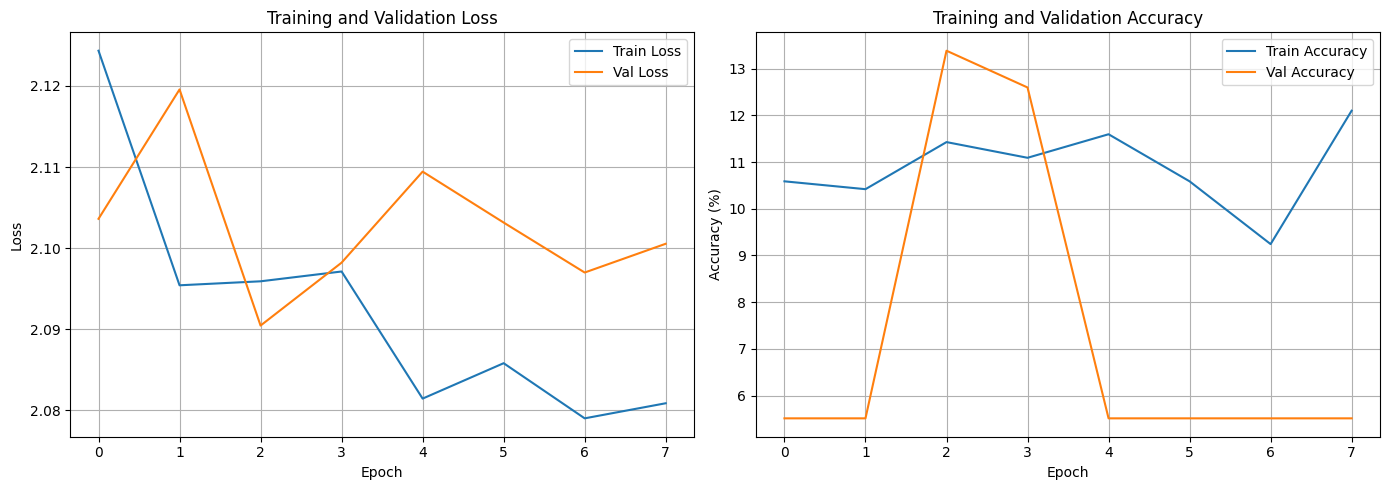

In [21]:
# Plot training and validation loss and accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accuracies, label='Train Accuracy')
ax2.plot(val_accuracies, label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


In [22]:
# Load best weights and evaluate on validation set
model.load_state_dict(torch.load('best of the best.pth', weights_only=True))
model.eval()

val_preds = []
val_labels = []

with torch.no_grad():
    for features, labels in val_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        _, predicted = torch.max(outputs, 1)
        val_preds.extend(predicted.cpu().numpy())
        val_labels.extend(labels.cpu().numpy())

print('Validation Set Classification Report:\n')
print(classification_report(val_labels, val_preds, target_names=[idx_to_class[i] for i in range(8)]))


Validation Set Classification Report:

                  precision    recall  f1-score   support

           AK-12       0.00      0.00      0.00        22
           AK-47       0.00      0.00      0.00        13
IMI Desert Eagle       0.00      0.00      0.00        16
        M-Family       0.00      0.00      0.00        24
            M249       0.13      1.00      0.24        17
           MG-42       0.00      0.00      0.00        15
             MP5       0.00      0.00      0.00        13
     Zastava M92       0.00      0.00      0.00         7

        accuracy                           0.13       127
       macro avg       0.02      0.12      0.03       127
    weighted avg       0.02      0.13      0.03       127



In [23]:
# Evaluate on test set and store final test accuracy
model.eval()

test_correct = 0
test_total = 0
test_preds = []
test_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * test_correct / test_total
print(f'Test Accuracy: {test_accuracy:.2f}%\n')
print('Test Set Classification Report:\n')
print(classification_report(test_labels, test_preds, target_names=[idx_to_class[i] for i in range(8)]))


Test Accuracy: 8.53%

Test Set Classification Report:

                  precision    recall  f1-score   support

           AK-12       0.00      0.00      0.00        19
           AK-47       0.00      0.00      0.00        10
IMI Desert Eagle       0.00      0.00      0.00        13
        M-Family       0.00      0.00      0.00        35
            M249       0.09      1.00      0.16        11
           MG-42       0.00      0.00      0.00        14
             MP5       0.00      0.00      0.00        17
     Zastava M92       0.00      0.00      0.00        10

        accuracy                           0.09       129
       macro avg       0.01      0.12      0.02       129
    weighted avg       0.01      0.09      0.01       129



In [24]:
# Final accuracy summary
print('Train Accuracy:     {:.2f}%'.format(train_accuracies[-1]))
print('Val Accuracy:       {:.2f}%'.format(val_accuracies[-1]))
print('Test Accuracy:      {:.2f}%'.format(test_accuracy))

Train Accuracy:     12.10%
Val Accuracy:       5.51%
Test Accuracy:      8.53%


In [25]:
# Self-contained inference wrapper — no external function dependencies
class AudioPipeline:
    def __init__(self, model, class_to_idx, idx_to_class):
        self.target_sr = 48000
        self.target_duration = 2.0
        self.n_mfcc = 40
        self.mfcc_params = {'n_fft': 1024, 'hop_length': 512, 'n_mels': 64}
        self.class_to_idx = class_to_idx
        self.idx_to_class = idx_to_class
        self.model = model.cpu()
        self.model.eval()

    def _convert_to_mono(self, waveform):
        if waveform.shape[0] > 1:
            return torch.mean(waveform, dim=0, keepdim=True)
        return waveform

    def _resample_audio(self, waveform, orig_sr):
        if orig_sr != self.target_sr:
            resampler = T.Resample(orig_sr, self.target_sr)
            return resampler(waveform)
        return waveform

    def _pad_or_crop(self, waveform, target_length):
        current_length = waveform.shape[1]
        if current_length < target_length:
            waveform = torch.nn.functional.pad(waveform, (0, target_length - current_length))
        elif current_length > target_length:
            waveform = waveform[:, :target_length]
        return waveform

    def _apply_preemphasis(self, waveform, coef=0.97):
        return torch.cat([waveform[:, :1], waveform[:, 1:] - coef * waveform[:, :-1]], dim=1)

    def _normalize_audio(self, waveform):
        return waveform / (torch.max(torch.abs(waveform)) + 1e-8)

    def _extract_mfcc(self, waveform):
        mfcc_transform = T.MFCC(
            sample_rate=self.target_sr,
            n_mfcc=self.n_mfcc,
            melkwargs=self.mfcc_params
        )
        return mfcc_transform(waveform)

    def predict(self, file_path):
        waveform, sr = torchaudio.load(file_path)
        waveform = self._convert_to_mono(waveform)
        waveform = self._resample_audio(waveform, sr)
        target_length = int(self.target_sr * self.target_duration)
        waveform = self._pad_or_crop(waveform, target_length)
        waveform = self._apply_preemphasis(waveform)
        waveform = self._normalize_audio(waveform)
        mfcc = self._extract_mfcc(waveform)
        mfcc = mfcc.unsqueeze(0)

        with torch.no_grad():
            output = self.model(mfcc)
            probabilities = torch.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        predicted_class = self.idx_to_class[predicted.item()]
        confidence_score = confidence.item() * 100
        return predicted_class, confidence_score


In [26]:
# Load best weights into model, move to cpu, wrap in AudioPipeline, save with joblib
model.load_state_dict(torch.load('best of the best.pth', weights_only=True))
pipeline = AudioPipeline(model, class_to_idx, idx_to_class)
joblib.dump(pipeline, 'gunshot_pipeline.joblib')
print('Saved gunshot_pipeline.joblib')


Saved gunshot_pipeline.joblib


In [27]:
# Load pipeline from disk and verify with a sample file from AK-47
loaded_pipeline = joblib.load('gunshot_pipeline.joblib')
sample_file = list(Path('gunshot-audio-dataset/AK-47').glob('*.wav'))[0]
pred_class, confidence = loaded_pipeline.predict(sample_file)
print(f'File: {sample_file.name}')
print(f'Predicted: {pred_class}')
print(f'Confidence: {confidence:.2f}%')


ImportError: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.

In [ ]:
# Ask for a wav file path and run inference using the saved pipeline
audio_input_path = input('Enter path to a .wav file: ').strip().strip('"').strip("'")

if not Path(audio_input_path).is_file():
    print(f'File not found: {audio_input_path}')
else:
    loaded_pipeline = joblib.load('gunshot_pipeline.joblib')
    pred_class, confidence = loaded_pipeline.predict(audio_input_path)
    print(f'Predicted: {pred_class}')
    print(f'Confidence: {confidence:.2f}%')


Predicted: M249
Confidence: 81.74%
